# Opium Snippets Topic Modelling

This notebook builds the first backbone of the topic modelling pipeline. Each extracted snippet is treated as one document, so the model captures the themes that appear around opium-related mentions rather than modelling whole books.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import re
import sys
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import StrMethodFormatter

from sklearn.linear_model import LinearRegression
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# Add parent directory to the search path
sys.path.append('..')   

from utils.topic_modelling import *
from utils.constants import KEYWORDS

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 180)

In [3]:
DATA_DIR = Path("../../data/snippets")
OUTPUT_DIR = Path("../../data/topic_modelling")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SNIPPETS_PARQUET = DATA_DIR / "total_snippets_with_gender.parquet"
SNIPPETS_CSV = DATA_DIR / "total_snippets_with_gender.csv"

RANDOM_STATE = 23

## Load Snippets as Documents

In [4]:
def load_snippets(parquet_path=SNIPPETS_PARQUET, csv_path=SNIPPETS_CSV):
    """Load snippets, preferring parquet because it keeps the intended schema clean."""
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    return pd.read_csv(csv_path, index_col=0)


df_raw = load_snippets()
df_raw.head()

,Unnamed: 0,Book_ID,Keyword,Snippet,Etext Number,Authors,LoCC,Published Year,Author Gender,Assigned_Gender,Character_Name
0,0,15,opium,"they would rather not see whales than otherwise. But all in vain; those young Platonists have a notion that their vision is imperfect; they are short-sighted; what use, then, t...",15,"Melville, Herman",PS,1851,male,Male,Whales
1,1,15,paregoric,"questionable; for it is not customary for such venerable leviathans to be at all social. Nevertheless, he stuck to their wake, though indeed their back water must have retarded...",15,"Melville, Herman",PS,1851,male,Male,Stubb
2,2,15,laudanum,"previous when the Pequod spoke the Town-Ho. According to this account and what was subsequently learned, it seemed that the scaramouch in question had gained a wonderful ascend...",15,"Melville, Herman",PS,1851,male,Male,Jeroboam
3,3,44,opium,"and scared you! Nothing to cry about. I’m the same old goods, only a little dented. Sit down on my coat there, and keep me company. I’ve got to lay still a bit.” Dr. Archie and...",44,"Cather, Willa",PS,1915,female,Female,Kronborg
4,4,95,narcotic,"that?” he asked. “Why this,” I answered. “That I shall ill requite the very great honours Ruritania has done me if I depart from it leaving one of those Six alive--neither with...",95,"Hope, Anthony",PR,1894,male,Male,Rupert Hentzau


In [5]:
df_raw.shape

(5370, 11)

In [6]:
df_raw["Keyword"].value_counts()

Keyword
opium             2609
morphine           564
narcotic           540
laudanum           503
anodyne            503
nepenthe           274
soporific          248
paregoric           82
heroin              30
codein              10
chandu               6
dover’s powder       1
Name: count, dtype: int64

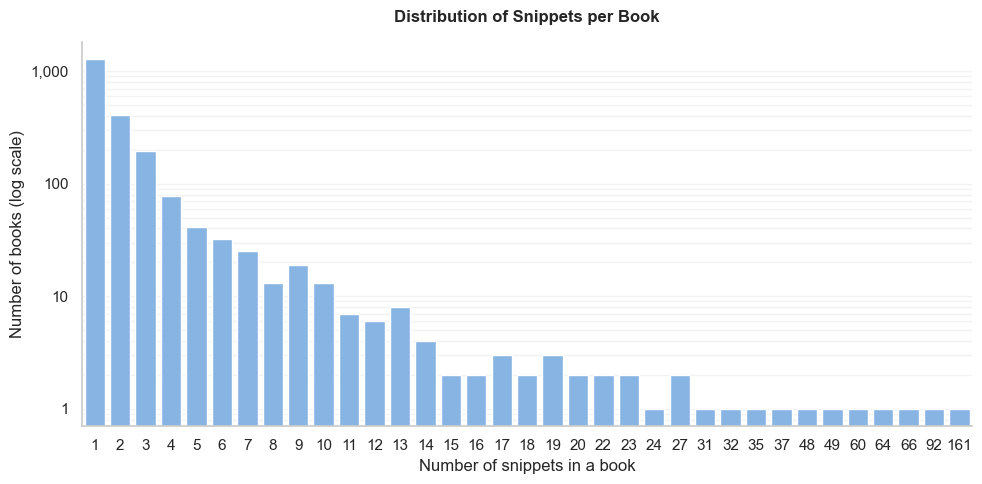

In [7]:
snippets_per_book = df_raw.groupby("Book_ID").size()
dist = snippets_per_book.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x=dist.index,
    y=dist.values,
    color="#79B3F2",
    ax=ax
)

ax.set_yscale("log")
ax.set_title("Distribution of Snippets per Book", pad=14, weight="bold")
ax.set_xlabel("Number of snippets in a book")
ax.set_ylabel("Number of books (log scale)")

ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", which="both", alpha=0.25)
ax.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()
plt.show()


In [8]:
snippets_per_book.describe()

count    2164.000000
mean        2.481516
std         5.592506
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       161.000000
dtype: float64

In [9]:
df_docs = df_raw.copy()
df_docs["snippet_id"] = df_docs.index
df_docs = df_docs[["snippet_id", "Book_ID", "Keyword", "Snippet"]]

print(f"Documents/snippets: {len(df_docs):,}")
print(f"Books represented: {df_docs['Book_ID'].nunique():,}")
df_docs["Keyword"].value_counts()

Documents/snippets: 5,370
Books represented: 2,164


Keyword
opium             2609
morphine           564
narcotic           540
laudanum           503
anodyne            503
nepenthe           274
soporific          248
paregoric           82
heroin              30
codein              10
chandu               6
dover’s powder       1
Name: count, dtype: int64

# LDA

## Prepare Text

In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[_\u2018\u2019\u201c\u201d]", " ", text)
    text = re.sub(r"-", " ", text)
    text = re.sub(r"[^a-z\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [11]:
# Creating a list of stop words specific to my corpus
df_stop_words = df_docs.copy()
df_stop_words["Snippet"] = df_stop_words["Snippet"].map(clean_text)
df_stop_words["words"] = df_stop_words["Snippet"].apply(lambda x: x.split(' '))
ALL_STOP_WORDS = ENGLISH_STOP_WORDS | set(KEYWORDS)
df_stop_words["words"] = df_stop_words["words"].apply(lambda x: [w for w in x if w not in ALL_STOP_WORDS])
df_stop_words

,snippet_id,Book_ID,Keyword,Snippet,words
0,0,15,opium,they would rather not see whales than otherwise but all in vain those young platonists have a notion that their vision is imperfect they are short sighted what use then to stra...,"[whales, vain, young, platonists, notion, vision, imperfect, short, sighted, use, strain, visual, nerve, left, opera, glasses, home, thou, monkey, said, harpooneer, lads, ve, c..."
1,1,15,paregoric,questionable for it is not customary for such venerable leviathans to be at all social nevertheless he stuck to their wake though indeed their back water must have retarded him...,"[questionable, customary, venerable, leviathans, social, stuck, wake, water, retarded, white, bone, swell, broad, muzzle, dashed, like, swell, formed, hostile, currents, meet, ..."
2,2,15,laudanum,previous when the pequod spoke the town ho according to this account and what was subsequently learned it seemed that the scaramouch in question had gained a wonderful ascenden...,"[previous, pequod, spoke, town, ho, according, account, subsequently, learned, scaramouch, question, gained, wonderful, ascendency, everybody, jeroboam, story, originally, nurt..."
3,3,44,opium,and scared you nothing to cry about i m the same old goods only a little dented sit down on my coat there and keep me company i ve got to lay still a bit dr archie and mr kronb...,"[scared, m, old, goods, little, dented, sit, coat, company, ve, got, lay, bit, dr, archie, mr, kronborg, disappeared, thea, cast, timid, glance, sat, resolutely, took, ray, s, ..."
4,4,95,narcotic,that he asked why this i answered that i shall ill requite the very great honours ruritania has done me if i depart from it leaving one of those six alive neither with the help...,"[asked, answered, shall, ill, requite, great, honours, ruritania, depart, leaving, alive, help, god, sapt, shook, hand, chapter, improvement, jacob, s, ladder, morning, day, sw..."
...,...,...,...,...,...
5365,5365,74690,narcotic,men called progress brought nothing but aches and pains and shortened lives civilization was all pretense and cosmetics months had passed since the theft of the telescope and j...,"[men, called, progress, brought, aches, pains, shortened, lives, civilization, pretense, cosmetics, months, passed, theft, telescope, joshua, racing, wildly, risking, life, doz..."
5366,5366,75372,anodyne,word was law moved softly up and down stairs in felt ward slippers carrying various mysterious burdens she called fenella at about midnight the girl had taken off her outer gar...,"[word, law, moved, softly, stairs, felt, ward, slippers, carrying, various, mysterious, burdens, called, fenella, midnight, girl, taken, outer, garments, fleecy, dressing, gown..."
5367,5367,75518,opium,then but not until formally invited fills his own cup and they drink ceremonially twice the cups are replenished then fadl anga says as namr d refills the clay bowl of the argi...,"[formally, invited, fills, cup, drink, ceremonially, twice, cups, replenished, fadl, anga, says, namr, d, refills, clay, bowl, argili, puts, tough, skinned, fingers, bit, glowi..."
5368,5368,75518,opium,shaykh sending out a volume of cigarette smoke have i not proved that true many times o shaykh g har and i also now son of my friend and ally go thou to the bath which as thou ...,"[shaykh, sending, volume, cigarette, smoke, proved, true, times, o, shaykh, g, har, son, friend, ally, thou, bath, thou, hast, turkish, yuzbashi, captain, command, guard, wired..."


In [12]:
word_counts = df_stop_words.words.explode().value_counts()
word_counts

words
s              6966
said           3122
t              2712
man            2279
like           2049
               ... 
bash              1
wush              1
zebub             1
ceremonious       1
outflung          1
Name: count, Length: 38781, dtype: int64

In [13]:
p = 0.25
snippets_proportion = p * df_stop_words.shape[0]
word_counts[word_counts >= snippets_proportion]

words
s         6966
said      3122
t         2712
man       2279
like      2049
time      1702
little    1695
did       1685
mr        1458
life      1425
know      1404
Name: count, dtype: int64

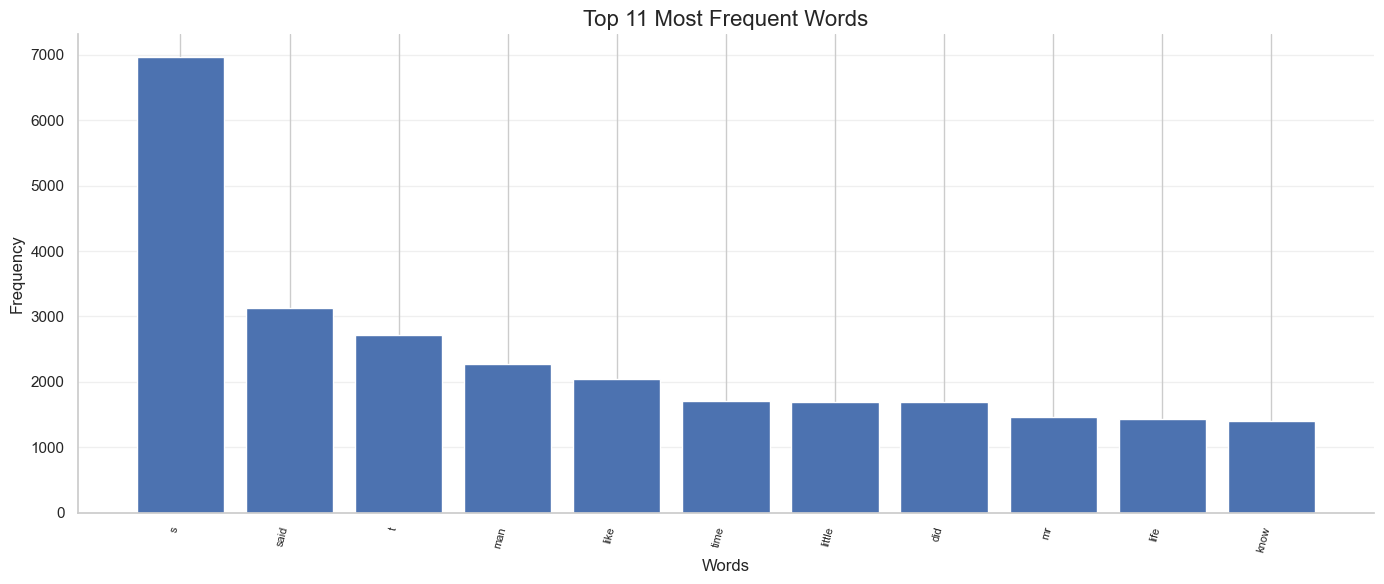

In [14]:
N = word_counts[word_counts >= snippets_proportion].shape[0]

# Keep only top N
top_words = word_counts.iloc[:N]

# Dynamic figure width so labels do not overlap too much
fig_width = max(14, N * 0.12)

plt.figure(figsize=(fig_width, 6))

plt.bar(
    range(len(top_words)),
    top_words.values
)

plt.title(f"Top {N} Most Frequent Words", fontsize=16)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xticks(
    ticks=range(0, len(top_words)),
    labels=top_words.index,
    rotation=75,
    ha="right",
    fontsize=8
)

plt.grid(axis="y", alpha=0.3)

# Remove top/right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
TARGET_TERMS = set(df_docs["Keyword"].str.lower().unique()) | set(KEYWORDS)

TARGET_TERMS = {
                token
                for word in TARGET_TERMS
                for token in re.findall(r"\b[a-z][a-z-]{2,}\b", word.lower())
}

PROJECT_STOP_WORDS = {"said", "say", "thou", "thy", "thee", 
                      "shall", "would", "could", "may", "like",
                      "did", "little", "mr", "mrs", "miss", "man", 
                      "men", "came", "come", "way", "went", "just",
                      "make", "took", "don", "yes", "tell", "thing",
                      "things", "know", "kenw", "thought", "think",
                       
                      } | set(word_counts.index[:N])


STOP_WORDS = sorted(ENGLISH_STOP_WORDS | PROJECT_STOP_WORDS | TARGET_TERMS)


df_docs["document"] = df_docs["Snippet"].map(clean_text)
df_docs = df_docs.loc[df_docs["document"].str.len() > 0].reset_index(drop=True)
documents = df_docs["document"].tolist()

df_docs[["snippet_id", "Keyword", "document"]].head()

,snippet_id,Keyword,document
0,0,opium,they would rather not see whales than otherwise but all in vain those young platonists have a notion that their vision is imperfect they are short sighted what use then to stra...
1,1,paregoric,questionable for it is not customary for such venerable leviathans to be at all social nevertheless he stuck to their wake though indeed their back water must have retarded him...
2,2,laudanum,previous when the pequod spoke the town ho according to this account and what was subsequently learned it seemed that the scaramouch in question had gained a wonderful ascenden...
3,3,opium,and scared you nothing to cry about i m the same old goods only a little dented sit down on my coat there and keep me company i ve got to lay still a bit dr archie and mr kronb...
4,4,narcotic,that he asked why this i answered that i shall ill requite the very great honours ruritania has done me if i depart from it leaving one of those six alive neither with the help...


## Vectorize Snippets

In [58]:
vectorizer = CountVectorizer(
    stop_words=STOP_WORDS,
    min_df=5,
    max_df=0.65,
    ngram_range=(1, 2),
    token_pattern=r"(?u)\b[a-z][a-z-]{2,}\b",
)

doc_term_matrix = vectorizer.fit_transform(documents)
feature_names = np.array(vectorizer.get_feature_names_out())

print(f"Document-term matrix: {doc_term_matrix.shape[0]:,} documents x {doc_term_matrix.shape[1]:,} terms")

Document-term matrix: 5,370 documents x 13,539 terms


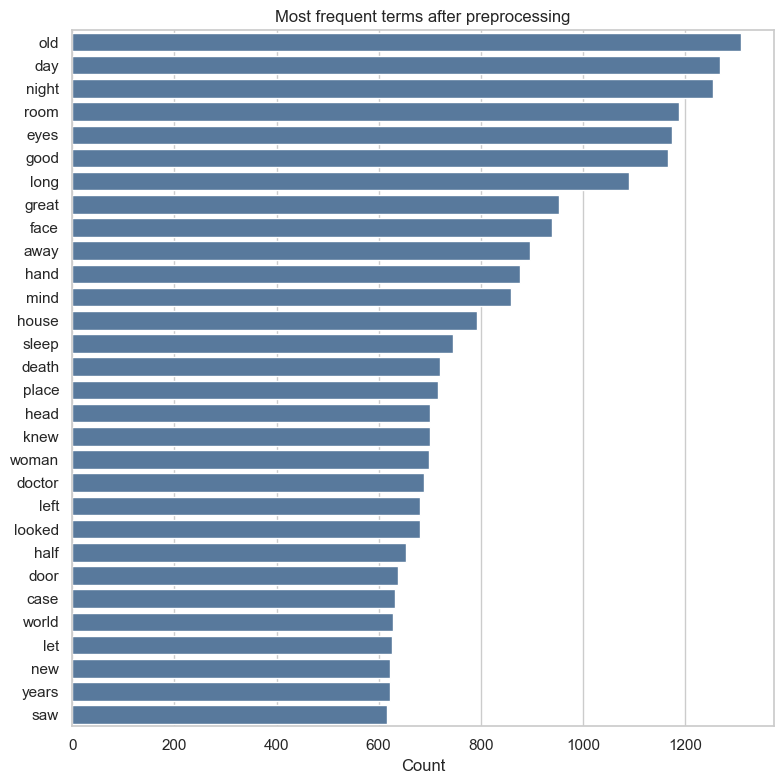

In [59]:
term_counts = np.asarray(doc_term_matrix.sum(axis=0)).ravel()
top_terms = (
    pd.DataFrame({"term": feature_names, "count": term_counts})
    .sort_values("count", ascending=False)
    .head(30)
)

plt.figure(figsize=(8, 8))
sns.barplot(data=top_terms, y="term", x="count", color="#4C78A8")
plt.title("Most frequent terms after preprocessing")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()

## Evaluate a range of reasonable numbers of topics

In [20]:
#TODO : correct paper?

#### Following this paper: 

Hong, M., Park, S. (2024). Application of Topic Modeling Techniques in Meta-analysis Studies. In: Hwang, H., Wu, H., Sweet, T. (eds) Quantitative Psychology. IMPS 2023. Springer Proceedings in Mathematics & Statistics, vol 452. Springer, Cham. https://doi.org/10.1007/978-3-031-55548-0_6 

We give an estimate of the number of topics that is suitable for our analysis, given our restricted number of documents. This approximation will help us narrowing down the tuning of the hyper parameter: number of topics, but the final decision on a sufficient number of topics will be given by manually inspecting and labelling the retrieved topics.

In [35]:
# The number of needed documents for a givne number of topics depends on the mean document length 
# which we previously fixed to 201 words by the definition of the opium context windows (100 words before and after the opium keyword)
# We inspect the actual lengths of the snippets.
snippets_lengths = df_raw["Snippet"].apply(lambda x: len(x.split(' ')))
display(snippets_lengths.value_counts())
print(snippets_lengths.unique())
print(snippets_lengths.mean())

Snippet
201    5365
190       1
171       1
202       1
150       1
174       1
Name: count, dtype: int64

[201 190 171 202 150 174]
200.9780260707635


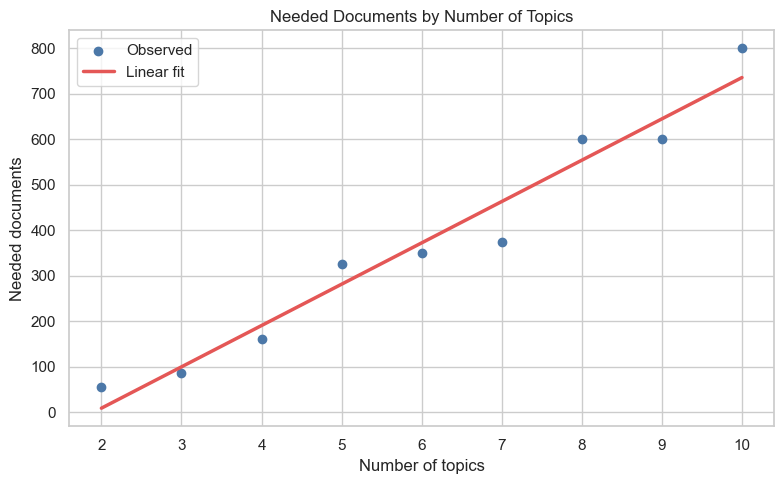

Intercept: -173.28
Slope: 90.92
R²: 0.958


In [36]:
# Taking the paper's estimate for a mean length of 200 words per documents (Table 1)
n_needed_docs = np.array([55, 85, 160, 325, 350, 375, 600, 600, 800])
n_topics = np.array(range(2, 11))

X = n_topics.reshape(-1, 1)
y = n_needed_docs

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(n_topics, n_needed_docs, color="#4C78A8", label="Observed")
plt.plot(n_topics, y_pred, color="#E45756", linewidth=2.5, label="Linear fit")

plt.xlabel("Number of topics")
plt.ylabel("Needed documents")
plt.title("Needed Documents by Number of Topics")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Intercept: {model.intercept_:.2f}")
print(f"Slope: {model.coef_[0]:.2f}")
print(f"R²: {model.score(X, y):.3f}")


In [37]:
max_nb_topics = math.floor((doc_term_matrix.shape[0] + model.intercept_) / model.coef_[0])
print(f"Maximum reasonable number of topics for our corpus : {max_nb_topics}")

Maximum reasonable number of topics for our corpus : 57


## Fit Candidate LDA Models

In [62]:
def fit_lda_model(n_topics, matrix=doc_term_matrix):
    model = LatentDirichletAllocation(
        n_components=n_topics,
        learning_method="batch",
        max_iter=25,
        random_state=RANDOM_STATE,
        evaluate_every=-1,
        n_jobs=6,
    )
    doc_topic = model.fit_transform(matrix)
    return model, doc_topic


candidate_topic_counts = range(2, 20) # We tune this, first by looking at perplexity and log likelihood
model_scores = []
candidate_models = {}

for n_topics in candidate_topic_counts:
    print(f"Computing topics for n_topics = {n_topics}...")
    model, doc_topic = fit_lda_model(n_topics)
    candidate_models[n_topics] = (model, doc_topic)
    model_scores.append({
        "n_topics": n_topics,
        "perplexity": model.perplexity(doc_term_matrix),
        "log_likelihood": model.score(doc_term_matrix),
    })

scores_df = pd.DataFrame(model_scores)
scores_df

Computing topics for n_topics = 2...
Computing topics for n_topics = 3...
Computing topics for n_topics = 4...
Computing topics for n_topics = 5...
Computing topics for n_topics = 6...
Computing topics for n_topics = 7...
Computing topics for n_topics = 8...
Computing topics for n_topics = 9...
Computing topics for n_topics = 10...
Computing topics for n_topics = 11...
Computing topics for n_topics = 12...
Computing topics for n_topics = 13...
Computing topics for n_topics = 14...
Computing topics for n_topics = 15...
Computing topics for n_topics = 16...
Computing topics for n_topics = 17...
Computing topics for n_topics = 18...
Computing topics for n_topics = 19...


,n_topics,perplexity,log_likelihood
0,2,5795.775066,-3.421174e+06
1,3,5827.139394,-3.423305e+06
2,4,5766.620795,-3.419183e+06
3,5,5885.611074,-3.427247e+06
4,6,6009.979766,-3.435503e+06
5,7,6038.317564,-3.437360e+06
6,8,6136.745053,-3.443744e+06
7,9,6229.410488,-3.449662e+06
8,10,6319.165492,-3.455310e+06
9,11,6472.157923,-3.464755e+06


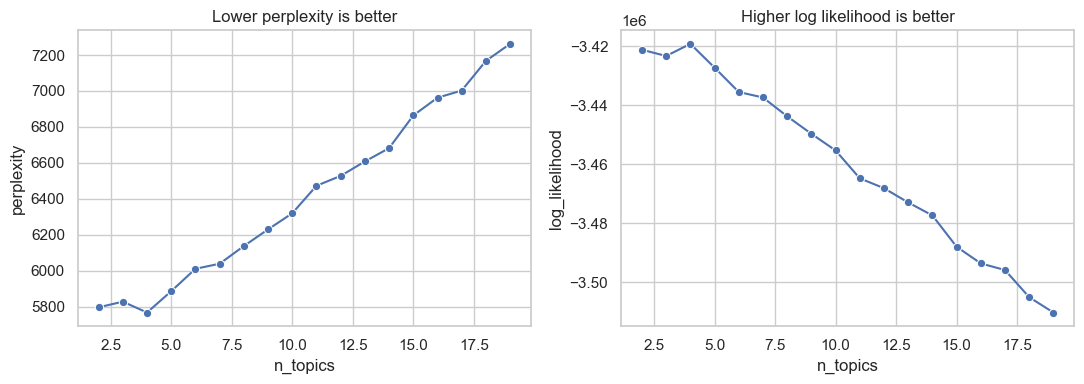

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(data=scores_df, x="n_topics", y="perplexity", marker="o", ax=axes[0])
axes[0].set_title("Lower perplexity is better")
sns.lineplot(data=scores_df, x="n_topics", y="log_likelihood", marker="o", ax=axes[1])
axes[1].set_title("Higher log likelihood is better")
plt.tight_layout()

Perplexity and likelihood are useful diagnostics, but the final topic count should also be readable. Start with the best perplexity value, then adjust `SELECTED_N_TOPICS` after inspecting the topic terms and snippets.

In [ ]:
SELECTED_N_TOPICS = int(scores_df.sort_values("perplexity").iloc[0]["n_topics"])
lda_model, doc_topic_matrix = candidate_models[SELECTED_N_TOPICS]

print(f"Selected topic count: {SELECTED_N_TOPICS}")

Selected topic count: 4


## Inspect Topics

In [66]:
def top_terms_by_topic(model, feature_names=feature_names, n_terms=15):
    rows = []
    for topic_idx, weights in enumerate(model.components_):
        top_indices = weights.argsort()[::-1][:n_terms]
        rows.append({
            "topic": topic_idx,
            "top_terms": ", ".join(feature_names[top_indices]),
        })
    return pd.DataFrame(rows)


topics_df = top_terms_by_topic(lda_model, n_terms=10)
topics_df

,topic,top_terms
0,0,"coleridge, quincey, english, eater, book, great, london, years, confessions, read"
1,1,"old, long, white, eyes, night, good, day, room, pipe, chinese"
2,2,"day, mind, old, love, good, great, world, long, heart, people"
3,3,"room, doctor, night, eyes, face, asked, hand, bed, case, looked"


In [67]:
for n in candidate_topic_counts:
    print('#'*20)
    print(f"USING {n} TOPICS:")
    df = top_terms_by_topic(candidate_models[n][0], n_terms=10)
    for _, (topic_n, top_terms) in df.iterrows():
        print(f"Topic n°{topic_n}: {top_terms}")

####################
USING 2 TOPICS:
Topic n°0: great, day, mind, world, years, good, old, love, work, coleridge
Topic n°1: room, night, eyes, old, face, hand, long, day, good, away
####################
USING 3 TOPICS:
Topic n°0: coleridge, quincey, english, eater, london, great, years, book, confessions, letters
Topic n°1: room, eyes, night, face, hand, door, head, doctor, old, looked
Topic n°2: day, old, good, mind, great, long, love, world, people, night
####################
USING 4 TOPICS:
Topic n°0: coleridge, quincey, english, eater, book, great, london, years, confessions, read
Topic n°1: old, long, white, eyes, night, good, day, room, pipe, chinese
Topic n°2: day, mind, old, love, good, great, world, long, heart, people
Topic n°3: room, doctor, night, eyes, face, asked, hand, bed, case, looked
####################
USING 5 TOPICS:
Topic n°0: quincey, coleridge, english, eater, book, read, great, confessions, poetry, years
Topic n°1: old, good, house, long, day, night, chinese, p

In [68]:
topic_columns = [f"topic_{i}" for i in range(SELECTED_N_TOPICS)]
doc_topics = pd.DataFrame(doc_topic_matrix, columns=topic_columns)

df_modelled = pd.concat([df_docs.reset_index(drop=True), doc_topics], axis=1)
df_modelled["dominant_topic"] = doc_topic_matrix.argmax(axis=1)
df_modelled["dominant_topic_weight"] = doc_topic_matrix.max(axis=1)

topic_summary = (
    df_modelled
    .groupby("dominant_topic")
    .agg(
        n_snippets=("snippet_id", "count"),
        n_books=("Book_ID", "nunique"),
        mean_weight=("dominant_topic_weight", "mean"),
    )
    .reset_index()
    .merge(topics_df, left_on="dominant_topic", right_on="topic", how="left")
    .drop(columns="topic")
    .sort_values("n_snippets", ascending=False)
)

topic_summary

,dominant_topic,n_snippets,n_books,mean_weight,top_terms
2,2,1951,1135,0.689936,"day, mind, old, love, good, great, world, long, heart, people"
3,3,1811,815,0.727537,"room, doctor, night, eyes, face, asked, hand, bed, case, looked"
1,1,1318,741,0.671555,"old, long, white, eyes, night, good, day, room, pipe, chinese"
0,0,290,120,0.743678,"coleridge, quincey, english, eater, book, great, london, years, confessions, read"


In [44]:
def representative_snippets(topic_id, n=5):
    topic_col = f"topic_{topic_id}"
    cols = ["snippet_id", "Book_ID", "Keyword", topic_col, "Snippet"]
    return (
        df_modelled
        .sort_values(topic_col, ascending=False)
        [cols]
        .head(n)
    )


representative_snippets(topic_id=1, n=5)

,snippet_id,Book_ID,Keyword,topic_1,Snippet
5218,5218,71118,opium,0.996862,"BY THOMAS HODGKIN, D. C. L. _Charles Auchester._ BY E. BERGER. _Character._ BY SAMUEL SMILES. _Charles O’Malley._ BY CHARLES LEVER. _Chesterfield’s Letters._ BY LORD CHESTERFIE..."
5168,5168,70252,opium,0.996862,"BY THOMAS HODGKIN, D. C. L. Charles Auchester. BY E. BERGER. Character. BY SAMUEL SMILES. Charles O’Malley. BY CHARLES LEVER. Chesterfield’s Letters. BY LORD CHESTERFIELD. Chev..."
4874,4874,63320,opium,0.996862,BY THOMAS HODGKIN. D. C. L. =Charles Auchester.= BY E. BERGER. =Character.= BY SAMUEL SMILES. =Charles O’Malley.= BY CHARLES LEVER. =Chesterfield’s Letters.= BY LORD CHESTERFIE...
3074,3074,31869,opium,0.996163,"Ebers. Burns' Poems. By Robert Burns. By Order of the King. By Victor Hugo. California and Oregon Trail. By Francis Parkman, Jr. Cast Up by the Sea. By Sir Samuel Baker. Caxton..."
2400,2400,17844,opium,0.995732,"Life of. By Thomas Hodgkin, D.C.L. Charles Auchester. By E. Berger. Character. By Samuel Smiles. Charles O'Malley. By Charles Lever. Chesterfield's Letters. By Lord Chesterfiel..."


Change `topic_id` in the previous cell to read examples from each topic. The snippets are the interpretive checkpoint: if top terms look plausible but the snippets do not cohere, adjust preprocessing or topic count.

## Save First Outputs

In [45]:
EXPORT_TO_CSV = True
if EXPORT_TO_CSV:
    topics_path = OUTPUT_DIR / f"lda_{SELECTED_N_TOPICS}_topics_terms.csv"
    doc_topics_path = OUTPUT_DIR / f"lda_{SELECTED_N_TOPICS}_document_topics.csv"
    summary_path = OUTPUT_DIR / f"lda_{SELECTED_N_TOPICS}_topic_summary.csv"

    topics_df.to_csv(topics_path, index=False)
    topic_summary.to_csv(summary_path, index=False)
    df_modelled.drop(columns=["document"]).to_csv(doc_topics_path, index=False)

    print(f"Saved topic terms to: {topics_path}")
    print(f"Saved topic summary to: {summary_path}")
    print(f"Saved document-topic weights to: {doc_topics_path}")

Saved topic terms to: ../../data/topic_modelling/lda_2_topics_terms.csv
Saved topic summary to: ../../data/topic_modelling/lda_2_topic_summary.csv
Saved document-topic weights to: ../../data/topic_modelling/lda_2_document_topics.csv


# BERTopic

For BERTopic moddeling, we use the embedding model `emanjavacas/MacBERTh`, from hugging-face, a historical English BERT model trained for the 1450-1950 period with sources that include British and American historical corpora.


NB: BERTopic will use those contextual embeddings to cluster snippets, then use class-based TF-IDF to describe each topic. Topic `-1` contains outlier snippets that HDBSCAN does not assign to a stable topic.

In [16]:
try:
    from bertopic import BERTopic
except ImportError as exc:
    raise ImportError(
        "BERTopic is not installed in this environment yet. "
        "Install the updated requirements with: pip install -r requirements.txt"
    ) from exc

## Fit BERTopic

In [23]:
HISTORICAL_EMBEDDING_MODEL = "emanjavacas/MacBERTh"

bertopic_vectorizer = CountVectorizer(
    stop_words=STOP_WORDS,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    token_pattern=r"(?u)\b[a-z][a-z-]{2,}\b",
)

bertopic_model = BERTopic(
    embedding_model=HISTORICAL_EMBEDDING_MODEL,
    vectorizer_model=bertopic_vectorizer,
    top_n_words=10,
    min_topic_size=50,
    nr_topics=None,#"auto",
    calculate_probabilities=True,
    verbose=True,
)

bertopic_topics, bertopic_probabilities = bertopic_model.fit_transform(documents)

2026-05-12 17:07:53,574 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emanjavacas/MacBERTh
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/168 [00:00<?, ?it/s]

2026-05-12 17:14:10,077 - BERTopic - Embedding - Completed ✓
2026-05-12 17:14:10,078 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-12 17:14:12,426 - BERTopic - Dimensionality - Completed ✓
2026-05-12 17:14:12,427 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-12 17:14:12,775 - BERTopic - Cluster - Completed ✓
2026-05-12 17:14:12,785 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-12 17:14:13,586 - BERTopic - Representation - Completed ✓


In [24]:
bertopic_model.reduce_topics(documents, nr_topics=20)

2026-05-12 17:14:20,575 - BERTopic - Topic reduction - Reducing number of topics
2026-05-12 17:14:20,576 - BERTopic - Topic reduction - Number of topics (20) is equal or higher than the clustered topics(11).
2026-05-12 17:14:20,576 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-12 17:14:23,804 - BERTopic - Representation - Completed ✓


## Inspect BERTopic Topics

In [25]:
bertopic_info = bertopic_model.get_topic_info()
bertopic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2584,-1_face_mind_head_place,"[face, mind, head, place, moment, far, turned, doctor, heard, world]",[her visit i am sorry i spoke of it thank you very much for coming to see me and for being so frank in a sense he was glad she had come for her coming had solved the difficulty...
1,0,919,0_got_doctor_asked_right,"[got, doctor, asked, right, face, head, dear, better, told, won]",[would be necessary for me to say what i am going to she continued but i overheard some things that were said that night and i have been thinking and then i heard the other day...
2,1,483,1_coleridge_quincey_world_eater,"[coleridge, quincey, world, eater, wordsworth, literature, poetry, true, confessions, mind]",[much at the hands of poets as from her french judges lamb induced coleridge to abandon these absurdities in midsummer coleridge met wordsworth and his exquisite sister dorothy...
3,2,363,2_place_chinese_sea_island,"[place, chinese, sea, island, gold, chinatown, small, police, high, face]",[himself for a pariah capable of the worst crimes and who may therefore be robbed beaten and even murdered by his white neighbors with impunity but when the police seek informa...
4,3,261,3_administered_poisoning_dose_witness,"[administered, poisoning, dose, witness, evidence, poison, died, diphtheria, doctor, opinion]",[they ask us to believe that the girl died from diphtheria or did she die of poison regardless of how she received it they do not choose between these two queries but ask you t...
5,4,187,4_felt_mind_love_sense,"[felt, mind, love, sense, soul, world, face, moment, physical, far]",[we call a sense of guilt added its deep depression it is not inability to comprehend his degradation his danger his utter loss of manhood which opium imposes on its wretched s...
6,5,173,5_floor_small_pipe_head,"[floor, small, pipe, head, face, stood, lamp, forward, held, moment]",[which has since been identified in my presence as that of mr jeffrey blackmore it was fully dressed and wore boots on which was a moderate amount of dry mud it was lying on it...
7,6,126,6_doctor_felt_face_soon,"[doctor, felt, face, soon, emily, branwell, voice, began, letter, returned]",[to drink it yet she said and put the laudanum into her dressing case her mind was not at ease when she had done this there seemed to be some indefinable ingratitude in the act...
8,7,115,7_love_soul_sweet_world,"[love, soul, sweet, world, rest, dear, hath, earth, song, sing]",[in view iv the butterfly safe under leaf and flower has found a roof knowing how true thou art the bumblebee within the last half hour has ceased to hug the honey to its heart...
9,8,100,8_dana_sahib_sending_englishman,"[dana, sahib, sending, englishman, face, water, heard, boat, till, kim]",[still going on but owing to some failure in the developing fluid they were not materialised the air was thick with letters for a few days afterwards unseen hands played gl ck ...


In [ ]:
def get_bertopic_terms(model, topic_id, n_terms=12):
    terms = model.get_topic(topic_id)
    if not terms:
        return ""
    return ", ".join(term for term, _ in terms[:n_terms])


bertopic_terms = pd.DataFrame({
    "topic": [topic_id for topic_id in bertopic_model.get_topics().keys()],
})
bertopic_terms["top_terms"] = bertopic_terms["topic"].map(
    lambda topic_id: get_bertopic_terms(bertopic_model, topic_id)
)

bertopic_terms = bertopic_terms.sort_values("topic").reset_index(drop=True)
bertopic_terms

,topic,top_terms
0,-1,"jasper, chinaman, says, arm, knowledge, experience, tobacco, poison, edwin, soft, answered, suppose"
1,0,"won, says, suppose, don know, isn, answered, couldn, ask, wouldn, ain, wasn, nodded"
2,1,"coleridge, quincey, literature, poetry, literary, genius, confessions, author, works, prose, poets, poet"
3,2,"poisoning, administered, witness, poison, symptoms, bliss, quantity, expert, professor, pupils, testimony, grains"
4,3,"loved, jocelyn, remorse, grief, knowledge, bitter, mary, mildred, awful, fate, hoped, hopeless"
5,4,"bowl, containing, label, arm, bunks, max, covered, tray, contained, oriental, piece, key"
6,5,"result, keith, gathered, noise, hearts, everybody, foreigners, members, dens, dick, objected, thieves"
7,6,"hath, hast, holy, sing, song, tis, sky, gods, stars, prophet, balm, forest"
8,7,"sky, huge, purple, doors, perfume, grotesque, scarlet, aromatic, moon, silver, market, gilded"
9,8,"carter, charles, coleridge, essays, thomas, william, confessions, quincey, poems, english eater, introduction, confessions english"


In [ ]:
df_bertopic = df_docs.copy()
df_bertopic["bertopic_topic"] = bertopic_topics

if bertopic_probabilities is not None and np.ndim(bertopic_probabilities) == 2:
    df_bertopic["bertopic_topic_probability"] = bertopic_probabilities.max(axis=1)
elif bertopic_probabilities is not None:
    df_bertopic["bertopic_topic_probability"] = bertopic_probabilities
else:
    df_bertopic["bertopic_topic_probability"] = np.nan

bertopic_summary = (
    df_bertopic
    .groupby("bertopic_topic")
    .agg(
        n_snippets=("snippet_id", "count"),
        n_books=("Book_ID", "nunique"),
        mean_probability=("bertopic_topic_probability", "mean"),
    )
    .reset_index()
    .merge(bertopic_terms, left_on="bertopic_topic", right_on="topic", how="left")
    .drop(columns="topic")
    .sort_values("n_snippets", ascending=False)
)

bertopic_summary

,bertopic_topic,n_snippets,n_books,mean_probability,top_terms
0,-1,2381,1243,0.126842,"jasper, chinaman, says, arm, knowledge, experience, tobacco, poison, edwin, soft, answered, suppose"
1,0,1212,721,0.398705,"won, says, suppose, don know, isn, answered, couldn, ask, wouldn, ain, wasn, nodded"
2,1,470,258,0.488079,"coleridge, quincey, literature, poetry, literary, genius, confessions, author, works, prose, poets, poet"
3,2,259,67,0.288283,"poisoning, administered, witness, poison, symptoms, bliss, quantity, expert, professor, pupils, testimony, grains"
4,3,250,202,0.434362,"loved, jocelyn, remorse, grief, knowledge, bitter, mary, mildred, awful, fate, hoped, hopeless"
5,4,163,115,0.434981,"bowl, containing, label, arm, bunks, max, covered, tray, contained, oriental, piece, key"
6,5,140,92,0.444078,"result, keith, gathered, noise, hearts, everybody, foreigners, members, dens, dick, objected, thieves"
7,6,135,106,0.495240,"hath, hast, holy, sing, song, tis, sky, gods, stars, prophet, balm, forest"
8,7,110,83,0.468676,"sky, huge, purple, doors, perfume, grotesque, scarlet, aromatic, moon, silver, market, gilded"
9,8,63,46,0.554829,"carter, charles, coleridge, essays, thomas, william, confessions, quincey, poems, english eater, introduction, confessions english"


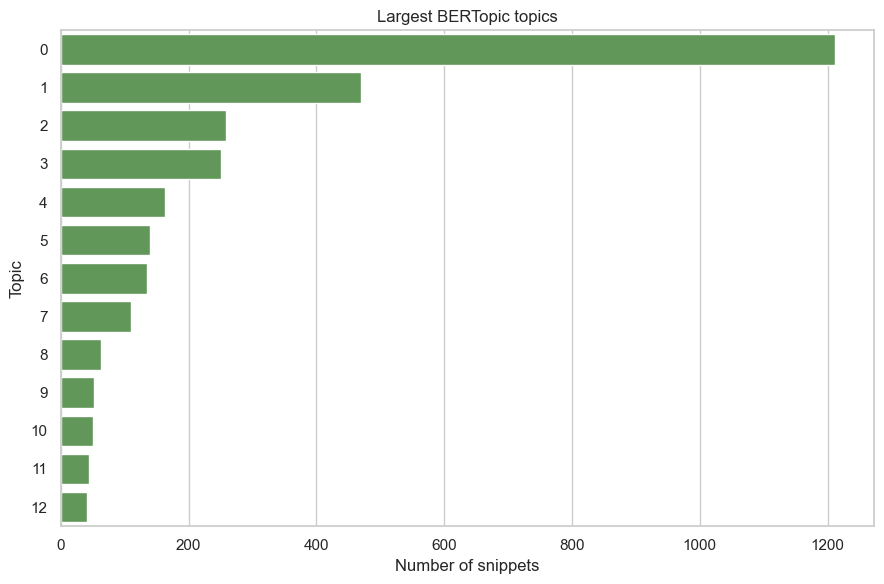

In [ ]:
plot_df = bertopic_summary.loc[bertopic_summary["bertopic_topic"] != -1].head(20)

plt.figure(figsize=(9, 6))
sns.barplot(data=plot_df, y="bertopic_topic", x="n_snippets", orient="h", color="#59A14F")
plt.gca().yaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))
plt.title("Largest BERTopic topics")
plt.xlabel("Number of snippets")
plt.ylabel("Topic")
plt.tight_layout()

In [ ]:
def representative_bertopic_snippets(topic_id, n=5):
    cols = ["snippet_id", "Book_ID", "Keyword", "bertopic_topic_probability", "Snippet"]
    return (
        df_bertopic
        .loc[df_bertopic["bertopic_topic"] == topic_id]
        .sort_values("bertopic_topic_probability", ascending=False)
        [cols]
        .head(n)
    )


representative_bertopic_snippets(topic_id=0, n=10)

,snippet_id,Book_ID,Keyword,bertopic_topic_probability,Snippet
2194,2194,14579,anodyne,1.0,"his preoccupation as if it were something physical about him. ""Explain, my dear,"" she said, leaning back and staring into the fire. ""I don't know that I can,"" he replied, and s..."
1114,1114,4547,opium,1.0,"welcome any one who came to Lalpore in his name. 'Accompanied by a small force,' added Colonel Starr in the vernacular, and the Maharajah also added, while Maun Rao behind him ..."
3630,3630,38049,morphine,1.0,best friend for years. Peace to his ashes. He leaves a sweeter memory behind him than any man I know. Poor Marmee is the last of her family now. _October._--Decided to go to B....
2107,2107,13709,morphine,1.0,"Yanks will corral me?"" I asks. ""'""Shore,"" he replies, ""but thar's nothin' else for it."" ""'It's then it comes on me about that gunboat an' the promises old Butler makes himse'f ..."
2706,2706,22731,paregoric,1.0,"all."" [Illustration: UPON THE BED LAY AS PRETTY A CHILD AS HE HAD EVER SEEN.] ""Warlock, dear boy,"" replied Wrangler, ""I think you told me you had never been an uncle. The man w..."
1730,1730,9790,opium,1.0,"knew spoke my tongue, having sailed to Calcutta often with horses. So I told him all my tale, using bazaar-talk, such as his kidney of Sahib would understand; and at the end I ..."
2117,2117,13763,opium,1.0,"to where he would turn in the wilderness for the commodity he so confidently mentioned. Then, the anguish returning, she checked his motion to depart. ""No, no, Peter,"" she said..."
1674,1674,9096,opium,1.0,"you the truth, mother, I don't trouble my head about such things. Philosophers are agreed that self consciousness is the bane of the present age: I mean to avoid it. If you had..."
732,732,2505,opium,1.0,"he was so far justified!’ ‘I had no time--at least I thought not. It would have been useless, for while these mysteries continue, my opinion is unchanged, and there was no bene..."
3809,3809,40140,opium,1.0,"have known this all day?"" she said reproachfully when he told her the truth. ""How unkind of you not to tell me!"" ""Unkind!"" he echoed. ""What possible good----"" ""I should have kn..."


Change `topic_id` above to inspect other BERTopic clusters. Topic `-1` is worth checking separately because a large outlier group usually means the model is finding many snippets too heterogeneous to cluster with the current settings.

In [ ]:
# Visualize the 

## Save BERTopic Outputs

In [ ]:
EXPORT_BERTOPIC_TO_CSV = True

if EXPORT_BERTOPIC_TO_CSV:
    bertopic_topics_path = OUTPUT_DIR / "bertopic_topics_terms.csv"
    bertopic_doc_topics_path = OUTPUT_DIR / "bertopic_document_topics.csv"
    bertopic_summary_path = OUTPUT_DIR / "bertopic_topic_summary.csv"
    bertopic_info_path = OUTPUT_DIR / "bertopic_topic_info.csv"

    bertopic_terms.to_csv(bertopic_topics_path, index=False)
    bertopic_summary.to_csv(bertopic_summary_path, index=False)
    bertopic_info.to_csv(bertopic_info_path, index=False)
    df_bertopic.drop(columns=["document"]).to_csv(bertopic_doc_topics_path, index=False)

    print(f"Saved BERTopic topic terms to: {bertopic_topics_path}")
    print(f"Saved BERTopic topic summary to: {bertopic_summary_path}")
    print(f"Saved BERTopic topic info to: {bertopic_info_path}")
    print(f"Saved BERTopic document-topic assignments to: {bertopic_doc_topics_path}")

Saved BERTopic topic terms to: ../../data/topic_modelling/bertopic_topics_terms.csv
Saved BERTopic topic summary to: ../../data/topic_modelling/bertopic_topic_summary.csv
Saved BERTopic topic info to: ../../data/topic_modelling/bertopic_topic_info.csv
Saved BERTopic document-topic assignments to: ../../data/topic_modelling/bertopic_document_topics.csv


### Split the snippets in sentences before fitting BERTopic